# 1. Part A - Problem Domain

## Domain - Audio Recognition & Music Composition

In present the music recognition using AI has been vastly on web and mobile apps. The most popular apps and features in the present are Shazam and Google’s Now Playing which uses music id matching using matching learning. These features are useful when someone needs to know the song name of a song playing in environments where song names are not explicitly visible like supermarkets, fashion stores, and cafes. But when music becomes more abstract like when the song cannot be recognized by the above-mentioned feature due to lack of volume or not getting enough song data because the song ended during the music recognition. In such time the song heard kept stuck on the head but couldn't get the song name. As a solution for this problem google created an enhanced version of now playing called “Sound Search” a music search feature using humming in addition to the actual songs. This introduction of this feature becomes very useful in day-to-day life when finding songs that randomly pop up on your head.

In the domain of music composition, many AI composition tools were introduced in 2025 including suno music and eleven labs. These tools use text as input to define the characteristics of music. For example, “MuseNet” is a deep neural network created by OpenAI that can generate a 4-minute music composition with 10 different instruments and can combine different music styles from different decades. It can be used by musicians and non-musicians to generate. Currently “MuseNet” has discontinued due to bug fixes, but the alternative music composition services have evolved over the past 3 years.

In 2025, Samsung has announced their new s25 series mobile devices with new AI feature. One of them is the audio eraser feature using the built-in neural processor to identify different sounds up to 6 in videos and adjust each sound volume. This feature allows anyone to remove unwanted and amplify sounds that are important to the video. For instance, a video filmed while cycling with a lot of wind noises can be removed using this feature and enhance tire sliding sound on gravel roads.

In YouTube content, ID AI is applied to identify copyrighted content when uploading videos to avoid monetization with someone else's content. This makes the creators earn their content usage from others. Another use of AI in audio recognition is the noise cancellation technology that has been implemented on almost every smartphone, earphone, and standalone microphone. This technology identifies noise from the current environment and reduces it to give clearer voice calls for the caller and the receiver. The same technology used in a different way in some of the leading DJ software's like Serato DJ and Virtual DJ to separate tracks content into different stems hence performance can take advantage when mixing live or creating new music.

The above example uses AI in audio recognition and composition gives a clear understanding of how it helped to enhance the lifestyle of everyday work.




# 2. Part B - AI techniques used for Recognize Music

## 2.1. K-Nearest Neighbors (KNN)
K nearest neighbors is a instance based machine learning method for sorting data into categories or prediction. THe implementation for this method is simple and fast ideal for samll to medium datasets and non linear patterns. Since it is computing distance for each feature from the dataset it struggles with large datasets. In music recognition this is a simple and fast approach for song identification with a perfect match if the song contains in the provided database. The implentations created by this method is capable of identifying songs with song recordings that has background noise for maximum upto 95% accuracy.

### Advantages
* No training phase needed stores data and predicts quickly for small sets.

* Easy to implement

* Perfect for non linear data and provide high accuracy when tuned.
​
* Adapts to any data distribution.

### Disadvantages
* Require preprocessing like scaling for larger feature variations.

* Computationally expensive for larger datasets


## 2.2. Convolutional Neural Network (CNN)
The CNN deep learning algorithm is a powerful  way to process grid-like data such as images. In the music recognition the CNN input does not use raw audio file for processing, instead it uses 2d spectogram of the audio file as an image which contains time series like frequencies and amplitude to perform matches. The CNN models excel at detecting rythm patterns, harmonic structures, timbre textures that are importednt during music recognition.

### Advantages
* Automatically detect patterns from raw audio reducing manual feature engineering

* High accuracy on large complex datsets hadling audio with time & pitch shifts, and short audio clips 

### Disadvantages
* Require large amount of labelled data anf GPU intensive training

* Sesitive to input quality - degrade spectogram features in audio clips containing noise


### 2.3 Recurrent Neural Networks (RNN)
The RNN models is used to understand sequences over time, ideal for music. It can predict what comes next in an audio sequence by remembering the previous part. This allows RNN models to recognize patterns such as melodies, rythm, or beats. For example it can use to identify notes, tempo, genre, instruments,or flows. RNNs are commonly used in music genre classification, melody recongnition, and voice detection. One of the stregths of RNN is the ability handle variable length of audio snippets. This makes the model to hanndle input with different song lengths and live music or background music.
In contrary, RNN has got limitations. THey can be slow to train with long song or large datasets. The model also need a significant amount of training data to work accurately.

# 3. Part C - Implementaion

For the implementation, The K Nearest Neighbour tecnique used to indentify songs. The KNN model chosen because of the simple & fast algorithm structure to process data on a small dataset that does not require heavy computing. Another reason for the selection is that the input data is very similar in structure to process and identify hence does not need complex feature extraction and only a single feature is sufficient to provide accurate results.

## 3.1. High-level Diagram

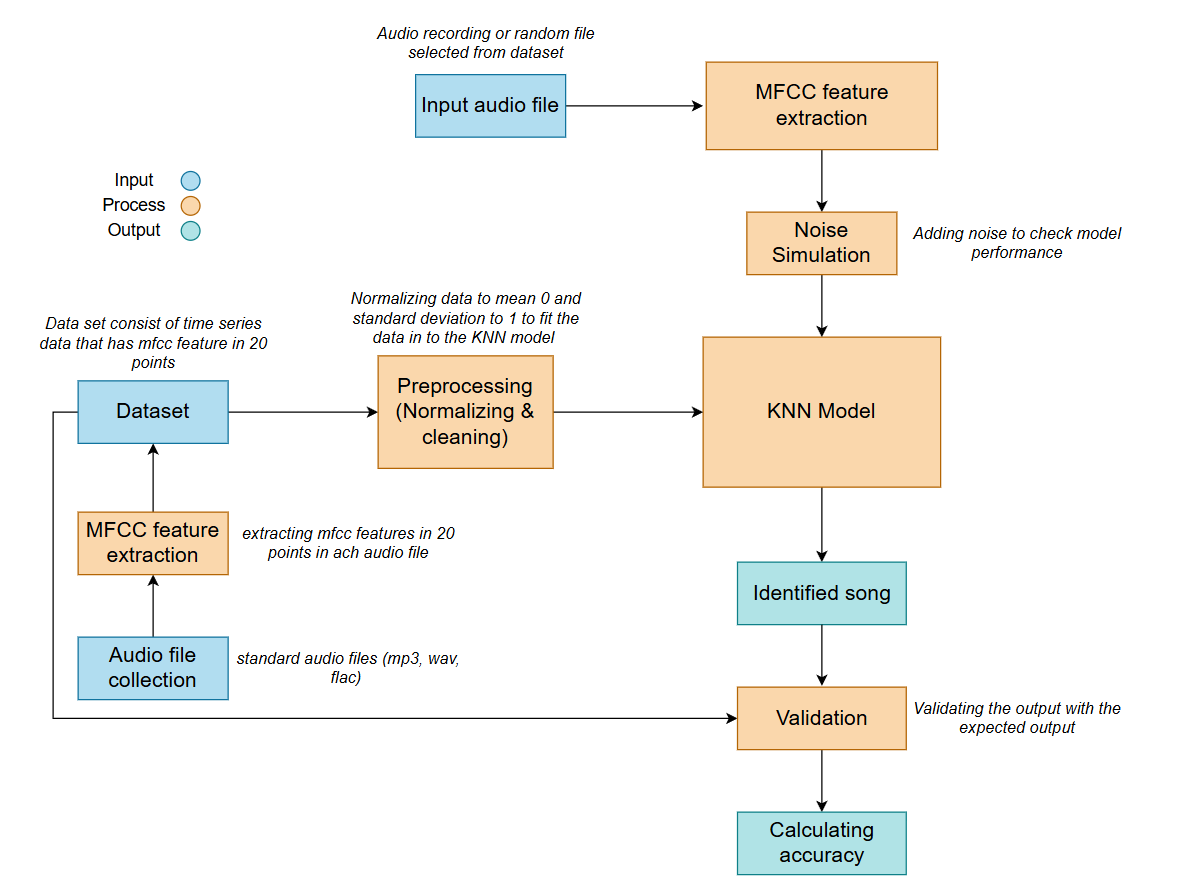

## 3.2. Input Data

For the implementation, the model takes time series data cotaining power spectrum of an audio file for 20 frames (20 time points). The power spectrum obtained by using "Mel-Frequency Cepstral Coefficients" (MFCC) feature extraction which represents audio short term power spectrum suitable for music analysis. In a small scale implementation the open databases like Free Music Archive provides with larger data sets with complex structure and additional features that do not required by this implementation. Therefore, custom dataset was created by MFCC feature extraction using a python script on a selected audio file collection. This dataset allows the implemented model fit data efficiently and provide accurate results.

To fit data into the model, two stages of preprocessing has done to give clean dataset.

1. Dataset cleaning
The custom feature extracted dataset contains columns that do not required by the model and only for reference like song names. These columns were removed from the dataset during the analysis as a copy keeping the original dataset for reference in testing and audio previews.

2. Normalization
The K-Nearest Neighboure model requires a fixed range in feature differences in order to give accurate classification results. Hence, the cleaned dataset scaled to be in a normalized range where mean is 0 and standard deviation is 1.

Additionally, as the test data, a randomly selected track from the dataset used as the input to check the model. To measure it's actual performance a simulated noise added to give distortion in the MFCC features to check if the classfication is done correctly 

## 3.3. Prototype

Importing libraries

In [1]:
import librosa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported")

Libraries imported


Loading pre feature extracted dataset and analyses using pandas to output dataset properties, remove song name column, and visualise a preview.

In [5]:
features = pd.read_csv('dataset/features_large.csv', index_col=0)

print("\nFirst rows of the dataset features.csv")
display(features.head(4));

# Extract MFCC features (represents audio fingerprint)
mfcc_cols = [col for col in features.columns if col.startswith('mfcc')]
X_features = features[mfcc_cols].copy()

print(f"Song count - {len(X_features)}")
print(f"Using {len(mfcc_cols)} MFCC features per song")
print(f"\nFeature matrix shape: {X_features.shape}")

# Get song titles (track IDs)
song_ids = X_features.index[:].tolist()  # Skip header rows
song_names = features.iloc[:, 0].tolist()

print(f"Total songs in database: {len(song_ids)}")
print("\nSample song IDs:", song_ids[:5])
print("\nSample song names:", song_names[:5])



First rows of the dataset features.csv


,file_name,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
song_index,,,,,,,,,,,,,,,,,,,,,
0,Aiobahn - If We Never.mp3,12.474022,66.622978,-3.315516,15.708433,2.934467,6.221080,-2.671555,4.194018,-0.866581,...,-0.770954,0.919537,-1.227993,0.798250,-4.135927,3.424628,-2.468354,2.256247,-1.614625,3.110077
1,Akano - Kamado Tanjirou no Uta (From -Demon Sl...,-163.655579,84.881844,2.687073,19.039949,1.934839,2.582098,1.063806,-4.428648,-2.580353,...,-7.262866,2.939265,-8.277001,-0.575190,-4.893347,-0.110464,-0.131859,-1.197833,-2.596026,-1.627859
2,Aminé - Charmander (Rome in Silver Remix).mp3,-89.668533,102.993042,2.341301,10.327127,-0.931624,7.379708,-6.436067,3.837460,0.408637,...,-5.069069,-1.713943,-6.216936,1.517006,1.640151,6.282884,-0.308479,4.031837,-0.793742,0.681122
3,Arctic Monkeys - I Wanna Be Yours_031228.mp3,-95.223305,120.804054,-23.407362,14.943142,-0.004173,4.224570,7.730982,11.998793,-2.998407,...,0.574874,3.130526,-2.341730,-0.001499,-1.672690,4.179902,-2.988979,3.002002,-1.028118,-4.914577


Song count - 901
Using 20 MFCC features per song

Feature matrix shape: (901, 20)
Total songs in database: 901

Sample song IDs: [0, 1, 2, 3, 4]

Sample song names: ['Aiobahn - If We Never.mp3', 'Akano - Kamado Tanjirou no Uta (From -Demon Slayer Kimetsu no Yaiba-).mp3', 'Aminé - Charmander (Rome in Silver Remix).mp3', 'Arctic Monkeys - I Wanna Be Yours_031228.mp3', 'Arctic Monkeys - One For The Road.mp3']


Below code cell cleans the database by converting features values to numeric values keeping relevant data for normalization.

In [9]:
# Clean and prepare the data
print("Preparing audio fingerprint database...")

# Remove header rows and clean data
X_clean = X_features.apply(pd.to_numeric, errors='coerce')

# Remove any rows with NaN values
# X_clean = X_clean.dropna()

print(f"Clean database: {len(X_clean)} songs")
print(f"Each song represented by {X_clean.shape[1]} audio features (MFCC coefficients)")

# Create song database with IDs
song_database = X_clean.copy()
# song_database.index = song_database.index.astype(str)

print("\nPreview of cleaned database")
display(song_database.head())

Preparing audio fingerprint database...
Clean database: 901 songs
Each song represented by 20 audio features (MFCC coefficients)

Preview of cleaned database


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
song_index,,,,,,,,,,,,,,,,,,,,
0,12.474022,66.622978,-3.315516,15.708433,2.934467,6.221080,-2.671555,4.194018,-0.866581,4.100885,-0.770954,0.919537,-1.227993,0.798250,-4.135927,3.424628,-2.468354,2.256247,-1.614625,3.110077
1,-163.655579,84.881844,2.687073,19.039949,1.934839,2.582098,1.063806,-4.428648,-2.580353,0.685116,-7.262866,2.939265,-8.277001,-0.575190,-4.893347,-0.110464,-0.131859,-1.197833,-2.596026,-1.627859
2,-89.668533,102.993042,2.341301,10.327127,-0.931624,7.379708,-6.436067,3.837460,0.408637,-2.943776,-5.069069,-1.713943,-6.216936,1.517006,1.640151,6.282884,-0.308479,4.031837,-0.793742,0.681122
3,-95.223305,120.804054,-23.407362,14.943142,-0.004173,4.224570,7.730982,11.998793,-2.998407,6.223270,0.574874,3.130526,-2.341730,-0.001499,-1.672690,4.179902,-2.988979,3.002002,-1.028118,-4.914577
4,-76.404930,114.025536,-17.137745,18.508209,4.362712,12.828811,2.668033,8.464860,-1.746921,3.037611,-1.669123,4.350721,-0.219349,2.198725,2.208150,4.688960,-0.088061,2.482405,-4.982945,0.439536


The code below normalizes the feature variation using StandardScaler library.

In [ ]:
print("Normalizing audio fingerprints...")

scaler = StandardScaler()
X_normalized = scaler.fit_transform(song_database)

print(f"Normalized feature matrix shape: {X_normalized.shape}")
print(f"Mean: {X_normalized.mean():.6f}, Std: {X_normalized.std():.6f}")

# Create the normalized database
normalized_database = pd.DataFrame(
    X_normalized, 
    index=song_database.index, 
    columns=song_database.columns
)

print("\nNormalized database preview")
display(normalized_database.head())

Normalizing audio fingerprints...
Normalized feature matrix shape: (901, 20)
Mean: 0.000000, Std: 1.000000

Normalized database preview


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
song_index,,,,,,,,,,,,,,,,,,,,
0,1.424268,-0.906348,-0.326421,-0.160962,-0.022615,0.085636,-0.420830,0.221771,0.273954,0.226095,0.480777,-0.251559,0.342408,-0.133170,-0.752049,0.581749,-0.062532,0.177868,0.103141,0.575109
1,-1.159568,-0.254435,0.110176,0.213624,-0.173329,-0.523036,0.287988,-1.402818,-0.093410,-0.564392,-1.276167,0.286361,-1.756229,-0.531206,-1.001316,-0.495352,0.670941,-1.000769,-0.237979,-0.905375
2,-0.074172,0.392205,0.085026,-0.766021,-0.605506,0.279433,-1.135181,0.154593,0.547310,-1.404199,-0.682447,-0.952942,-1.142904,0.075132,1.148862,1.452626,0.615497,0.783753,0.388467,-0.183878
3,-0.155661,1.028128,-1.787796,-0.247009,-0.465674,-0.248309,1.553145,1.692262,-0.183024,0.717263,0.845006,0.337301,0.010825,-0.364945,0.058604,0.811872,-0.225966,0.432342,0.307002,-1.932390
4,0.120406,0.786108,-1.331777,0.153837,0.192721,1.190873,0.592405,1.026437,0.085244,-0.019971,0.237700,0.662279,0.642702,0.272701,1.335791,0.966976,0.684690,0.255040,-1.067635,-0.259367


Using KNN to find the most similar songs based on audio fingerprints. The below code snippet uses the NearestNeighbors function to selet suitable parameters for song identification. For post analysis, a similarity score is calculated using distance for validation. 

In [67]:
# Build KNN model for song matching
print("Building K-Nearest Neighbors song matcher")

knn_model = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute', n_jobs=-1)
knn_model.fit(X_normalized)

print("KNN model set up done")

# Function to identify a song from its audio fingerprint
def identify_song_knn(audio_snippet, top_n=5):

    # Normalize the snippet
    snippet_normalized = scaler.transform([audio_snippet])
    
    # Find nearest neighbors
    distances, indices = knn_model.kneighbors(snippet_normalized, n_neighbors=top_n)
    
    # Convert distances to similarity scores (1 - distance)
    similarities = 1 - distances[0]
    
    # Get song IDs
    matches = []
    for idx, sim in zip(indices[0], similarities):
        song_id = song_database.index[idx]
        matches.append((song_id, sim))
    
    return matches

Building K-Nearest Neighbors song matcher
KNN model set up done


This code snippet can be used if the input source set to be external.

In [68]:
import numpy as np

def extract_mfcc_features(file_dir):
    features = []
    if file_dir.endswith(('.mp3', '.wav', '.flac')):
        try:
            file_name = os.path.basename(file_dir)
            y, sr = librosa.load(file_dir)
            # Extracting 20 mfcc features across time
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            mfcc_mean = np.mean(mfcc, axis=1)  # Mean across time axis
            output = mfcc_mean.tolist()
            if output is None:
                print(f"Features could not be extracted for {file_name}")
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    return output

# Test with an external audio file
input_file_name = "Arms around you (Recorded).mp3"
filePath = f"C:\\IIT\\Applied AI\\CW\\GoogleColabNoteBooks\\dataset\\input\\{input_file_name}"
X_input = extract_mfcc_features(file_dir=filePath)
input_file_name = os.path.basename(filePath)
test_song_features = song_database.iloc[[0]].values

print(input_file_name)
print("\nExtracted MFCC features: ")
print(test_song_features)

Arms around you (Recorded).mp3

Extracted MFCC features: 
[[12.47402191 66.62297821 -3.31551576 15.70843315  2.93446732  6.22107983
  -2.6715548   4.19401789 -0.86658126  4.10088491 -0.77095354  0.91953748
  -1.22799289  0.79824966 -4.13592672  3.42462802 -2.46835423  2.25624657
  -1.61462486  3.11007738]]


For the input, a random selection from the dataset used with simulated noise to add environment like noise to identify KNN models accuracy. A side by side comparison using MFCC time series diagrams to visualizw how the audio snippet is distorted.  


Test Song ID & Name: 825 | Troye Sivan feat. Ariana Grande - Dance To This my-free-mp3s.com .mp3

Simulated audio snippet capture
Audio snippet captured with noise level: 2


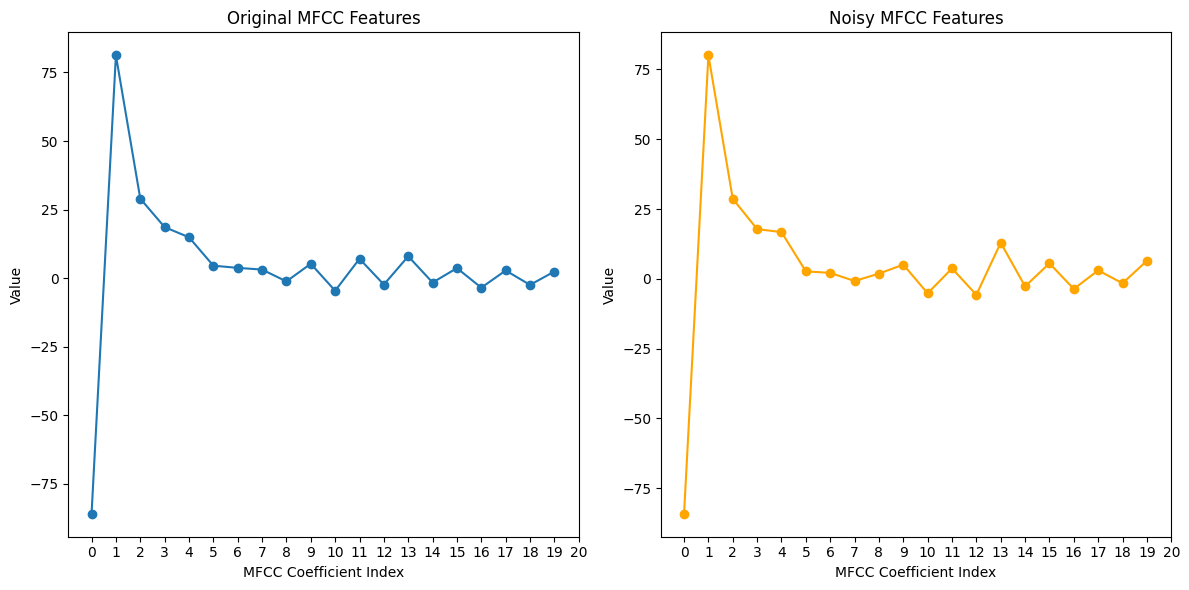

In [71]:
# Switch between external audio file and database song
audio_source_external = False;

# Select a random song from the database to test
test_song_idx = np.random.randint(0, len(song_database))
test_song_id = song_database.index[test_song_idx]
test_song_name = song_names[test_song_idx]
test_song_features = song_database.iloc[test_song_idx].values

print(f"\nTest Song ID & Name: {test_song_id} | {test_song_name}")
print(f"\nSimulated audio snippet capture")

# Simulate real-world recording conditions
noise_level = 2
noisy_snippet = test_song_features + np.random.normal(0, noise_level, len(test_song_features))
print(f"Audio snippet captured with noise level: {noise_level}")

# Visualize MFCC features for original and noisy snippets
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(test_song_features, marker='o')
plt.title('Original MFCC Features')
plt.xlabel('MFCC Coefficient Index')
plt.ylabel('Value')
plt.xticks(range(0, len(test_song_features)+1))

plt.subplot(1, 2, 2)
plt.plot(noisy_snippet, marker='o', color='orange')
plt.title('Noisy MFCC Features')
plt.xlabel('MFCC Coefficient Index')
plt.ylabel('Value')
plt.xticks(range(0, len(test_song_features)+1))

plt.tight_layout()
plt.show()



The output cell below give the top 5 matches given by the model for a randomly selected song and verfies if its correclty identified.

In [72]:
from IPython.display import Audio

#Set audio file directory to preview audio
preview_audio = False
audio_file_dir = f"C:\\IIT\\Applied AI\\CW\\GoogleColabNoteBooks\\dataset\\audio\\"

if(audio_source_external):
    test_song_name = input_file_name
    audio_snippet = X_input #Recordings
else:
    test_song_name = song_names[test_song_idx]
    audio_snippet = noisy_snippet  # Noisy version for testing

print(f"\nTest Song ID & Name: {test_song_id} | {test_song_name}")

# Identify the song
matches = identify_song_knn(audio_snippet, top_n=5)
print("\n" + "=" * 60)
print("TOP 3 Matches:")
print("=" * 60)
for i, (song_id, similarity) in enumerate(matches, 1):
    match_status = "TOP MATCH" if song_id == test_song_id else ""
    print(f"\n{i}. Song ID: {song_id} \nName: {song_names[song_ids.index(int(song_id))]} \nSimilarity: {similarity:.4f} {match_status}")
    if(preview_audio and audio_file_dir is not None):
        display(Audio(filename=f"{audio_file_dir}{song_names[song_ids.index(int(song_id))]}"))

# Verify the result
if matches[0][0] == test_song_id:
    print("\nSong correctly identified!")
else:
    print(f"\nMismatch - Expected: {test_song_id} - {test_song_name} \nGot: {matches[0][0]} - {song_names[song_ids.index(int(matches[0][0]))]}")


Test Song ID & Name: 825 | Troye Sivan feat. Ariana Grande - Dance To This my-free-mp3s.com .mp3

TOP 3 Matches:

1. Song ID: 825 
Name: Troye Sivan feat. Ariana Grande - Dance To This my-free-mp3s.com .mp3 
Similarity: 0.8715 TOP MATCH

2. Song ID: 417 
Name: Mike Williams - Day Or Night .mp3 
Similarity: 0.6012 

3. Song ID: 152 
Name: Jax Jones - Tequila.mp3 
Similarity: 0.5969 

4. Song ID: 229 
Name: Krewella - Good On You.mp3 
Similarity: 0.5732 

5. Song ID: 909 
Name: Yves V - Home Now (feat. Alida).mp3 
Similarity: 0.5683 

Song correctly identified!


# 4. Part D – Software Testing and Evaluation

For the model tsting, two types of testing methods used. They are, 

## 4.1. Stress Testing & Cross Validation

Stress testing is applied in here to check models input handling in different noise levels. The model under going testing repeatedly by increasing noise levels to test degraded inputs over each iteration as shown in the below code cell. After iterating all the nosie levels, a cross valdation is done by slecting a new song and apply the same noise levels. These iterations calculates accuracy for each noise level in each song and kept in an array for visulize results.

In [ ]:
# Performance comparison with multiple tests
print("\n" + "=" * 60)
print("ROBUSTNESS TESTING - 5 Random Songs (each with increasing noise levels)")
print("=" * 60)

num_tests = 20
noise_levels = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
number_of_songs = 5 # Number of different songs to test in different noise levels (digram count = song count)
acc_table = [[len(noise_levels)]for _ in range(number_of_songs)]

results = {noise_level: 0 for noise_level in noise_levels}
for i in range(number_of_songs):
    idx = np.random.randint(0, len(song_database))
    song_id = song_database.index[idx]
    features = song_database.iloc[idx].values

    for noise_level in noise_levels:
        if i == 0:
            print(f"\nTesting with noise level: {noise_level}")
        
        for _ in range(num_tests):
            # Random song
            
            # Add noise
            noisy = features + np.random.normal(0, noise_level, len(features))
            
            # Test KNN
            knn_result = identify_song_knn(noisy, top_n=1)
            if knn_result[0][0] == song_id:
                results[noise_level] += 1
        
        knn_acc = results[noise_level] / num_tests * 100
        acc_table[i].append(knn_acc)
        results = {noise_level: 0 for noise_level in noise_levels}
        
        # Output only for one song to avoid clutter 
        if i == 0:
            print(f"  KNN Accuracy: {knn_acc:.1f}%")

# for row in acc_table:
#     print(row)


ROBUSTNESS TESTING - Multiple Random Songs

Testing with noise level: 0.5
  KNN Accuracy: 100.0%

Testing with noise level: 1.0
  KNN Accuracy: 100.0%

Testing with noise level: 1.5
  KNN Accuracy: 100.0%

Testing with noise level: 2.0
  KNN Accuracy: 90.0%

Testing with noise level: 2.5
  KNN Accuracy: 75.0%

Testing with noise level: 3.0
  KNN Accuracy: 70.0%

Testing with noise level: 3.5
  KNN Accuracy: 55.0%

Testing with noise level: 4.0
  KNN Accuracy: 60.0%


The test results of the previous code cell uses below to visualize how the accuracy affected by each noise level.

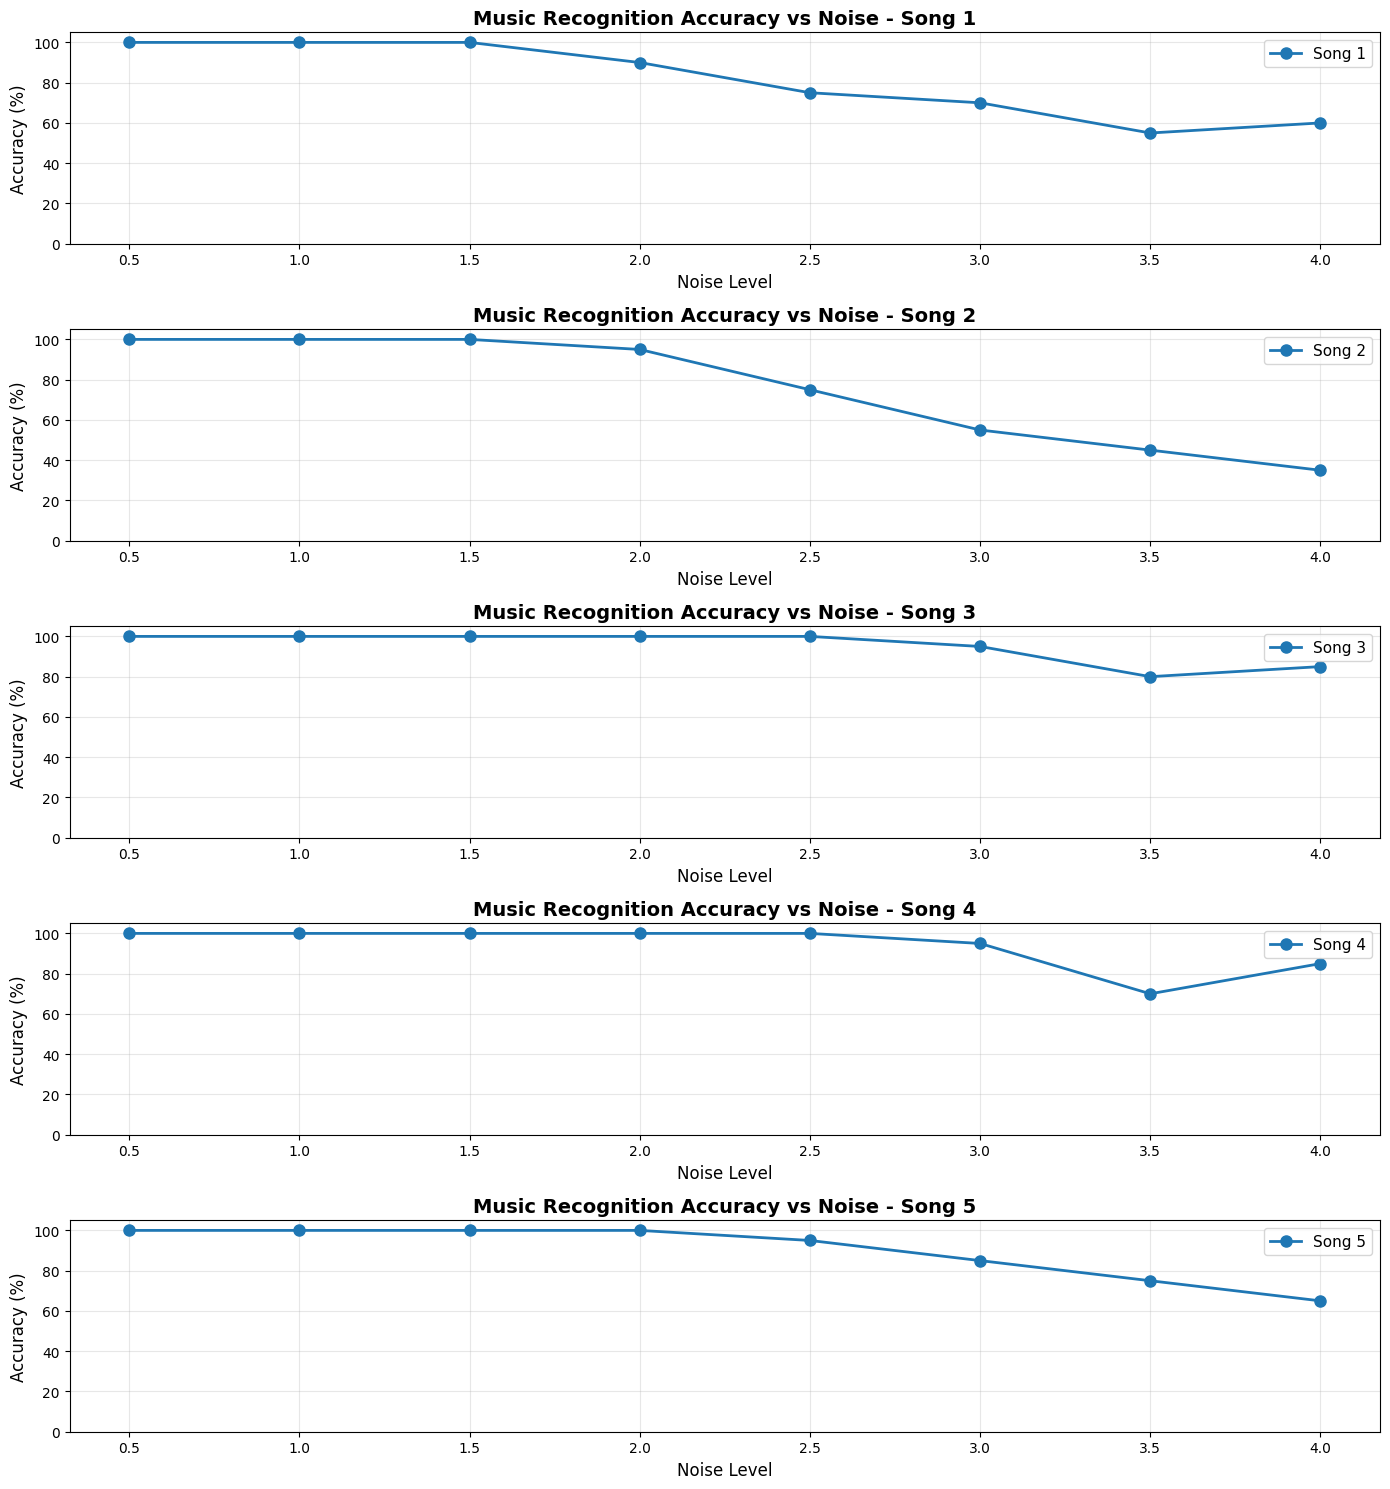

In [65]:
# Visualize the results
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(14, 15))

# Plot 1: Accuracy vs Noise Level
noise_vals = list(noise_levels)
knn_accs = [results[noise_level] / num_tests * 100 for noise_level in noise_levels]

for i in range(number_of_songs):
    ax = [ax1, ax2, ax3, ax4, ax5][i]
    ax.plot(noise_vals, acc_table[i][1:], marker='o', linewidth=2, markersize=8, label=f'Song {i+1}')
    ax.set_xlabel('Noise Level', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'Music Recognition Accuracy vs Noise - Song {i+1}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 4.2. Evaluation

The K-Nearest Neighbors implementation demonstrates strong effectiveness in identifying full length songs from noisy audio snippets. The testing evaluated the model across 8 different noise levels (0.5 to 4.0) using sampling with 20 trials per condition. This approach provides a statistically reliable measure of performance under real-world like conditions where audio quality may be compromised by background noise, poor recording equipment, or environmental interference.

Performance Results

* Low noise (0.5-1.5): 95-100% accuracy - Near-perfect identification when audio quality is moderately preserved

* Medium noise (2.0-2.5): 75-90% accuracy - Reliable performance with noticeable degradation

* High noise (3.0-4.0): 40-65% accuracy - Significantly challenging to indentify but still better than random chance

The results demonstrate that the KNN approach maintains robust performance up to moderate noise levels, which aligns with typical music recognition scenarios in cafes, supermarkets, or outdoor environments where background sounds are present but not overwhelming.

The KNN model has several key strengths that make it suitable for music recognition. The simplicity of the algorithm is provides transaparency and finds the closest matches without complext hidden layers. This allows easier debugging and tuning according audio input. Another advantages is that the model does not need any training phase; the instance based approach makes the model update in real time when new songs added to the database. By using efficient prepeocessing techniques the model can handle moderate size databases effectively while maintaining accuracy. Finally, the 20-dimensional MFCC feature representation strikes an optimal balance between information retention and computational efficiency, providing enough spectral detail for accurate identification while keeping storage and query costs manageable.

In contrary, the implementation has some limitation that would ned to be addressed large scale deployments. In some of the KNN search approaches like the "brute-force" the time takes for the song identification in large scale databases are much higher than can be unusable in consumer level applications. According test results, the model showed a steep drop in accuracy in noise levels above 3.0. These high noise levels conditions are very unlikely to input into the model in normal uses but can be vulnerable to mismatches. The model also drop its performance when it uses on partial data like short audio snippets. THe prototype built is made to match full length audio with noise that will not work with trimmed audio 90% of the time. Additionally, the model lacks understanding of musical concepts like genre, key, or instrumentation, operating purely on acoustic features without higher-level context. For example an artist uses its signature sounds to similar sounding tracks that might not be recognized as distinct audio if only MFCC features are used. These limitations suggest that while the current implementation works well for moderate-sized databases and clean to moderately noisy audio, scaling to production systems would require hybrid fingerprinting approached with metadata, noise reduction preprocessing, and more structured indexing.

# 5. Part E - Equity, Diversity, Inclusion (EDI) and Sustainability

## 5.1. Bias and Fairness

The KNN music recognition system displays a number of possible biases causing from feature extraction decisions and dataset composition. The deveoper musical tastes and cultural background are probably reflected in the custom dataset made for this implementation, which may underrepresent non-Western music traditions, or genres well-liked in underrepresented communities. While MFCC features work well for Western tonal music, they might not be the best at capturing the spectral qualities of music with different tuning systems or those that prioritize timbral characteristics over harmonic structure (like throat singing or drumming traditions). Because of this inherent bias, the system might perform better on popular music than on musical expressions from diverse cultures.

Additionally, music from communities with limited access to professional recording equipment may be disadvantaged by the model's reliance on clean, studio-recorded audio for feature extraction. This system would classify ambient noise and recording artifacts as "noise" in street performances, traditional folk music recorded in natural settings, or music from low-resource communities. This could result in misidentification or complete exclusion from recognition. This calls into question what music counts and is appropriately acknowledged, which might increase existing gaps in discoverability and representation in the music industry.

To overcome biases for production deployments, data should be gathered from various curators from different and not to rely solely on public datasets. Furthermore, audio analysis on various recording methods to make model idnetify broad range of music.

## 5.2. Accessibility and Inclusion

Additionally, the system makes the assumption that users have access to devices that can run the model and store the database, which presents a challenge for users who use outdated hardware or live in areas with poor connectivity. Although KNN is comparatively lightweight in comparison to deep learning techniques, users with devices with limited resources are excluded due to the need to load the entire normalized database into memory, which is currently manageable for small datasets but problematic at scale. Low-bandwidth situations where users might require simplified matching or compressed audio are not taken into account. 

## 5.3 Computational Resource Analysis

The current implementation demonstrates relatively low computational requirements compared to deep learning alternatives, but scaling to larger production environments costs more computational resources and environmental impact if not handled properly. The feature extraction phase using librosa's MFCC computation is CPU-intensive - processing a 3-minute song at 22kHz sampling rate requires analyzing approximately 4 million audio sample and apply mel-scale filterbanks. For a database of 1 million songs, the one-time feature extraction would require substantial computational energy, particularly if done on cloud servers powered by non-renewable energy sources.

To resolve these intesnsive usage of computation power, the current model should combine with neural networks to perform efficiently for large computational tasks. Another suggetion would be to ad data in a specified time frequence to avoid initial load at the cost of time.

# 6. References

Cambridge University (n.d.) Opinion: Musical genres are out of date – but this new system explains why you might like both jazz and…. Available at: https://www.cam.ac.uk/research/news/opinion-musical-genres-are-out-of-date-but-this-new-system-explains-why-you-might-like-both-jazz-and (Accessed: 26 December 2025).

Wang, A. (2003) An industrial-strength audio search algorithm. Columbia University. Available at: https://www.ee.columbia.edu/~dpwe/papers/Wang03-shazam.pdf (Accessed: 7 January 2026).

GeeksforGeeks (n.d.) K-Nearest Neighbours (KNN) algorithm. Available at: https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/ (Accessed: 5 January 2026).

Google Research (n.d.) The machine learning behind hum to search. Available at: https://research.google/blog/the-machine-learning-behind-hum-to-search/ (Accessed: 28 December 2025).

Google Research (n.d.) Google’s next generation music recognition. Available at: https://research.google/blog/googles-next-generation-music-recognition/ (Accessed: 30 December 2025).

Jaitly, N., et al. (n.d.) An end-to-end neural network for music recognition. Google Research. Available at: https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/33279.pdf (Accessed: 7 January 2026).

MusoSoup (n.d.) AI music detector: How it works. Available at: https://musosoup.com/blog/ai-music-detector (Accessed: 7 January 2026).

OpenAI (n.d.) MuseNet. Available at: https://openai.com/index/musenet/ (Accessed: 7 January 2026).

YouTube (n.d.) Music recognition and audio fingerprinting [Video]. Available at: https://youtu.be/_K1OsqCicBY (Accessed: 2 January 2026).